# Spectral fitting example (GRB)

**To run this, you need the following files, which can be downloaded using the first few cells of this notebook:**
- orientation file (20280301_3_month_with_orbital_info.fits)       
- binned data (grb_binned_data.hdf5 & bkg_binned_data_1s_local.hdf5)     
- detector response (SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5)     

**The binned data are simulations of GRB090206620 and albedo photon background produced using the COSI SMEX mass model. The detector response needs to be unzipped before running the notebook.**

This notebook fits the spectrum of a GRB simulated using MEGAlib and combined with background.

[3ML](https://threeml.readthedocs.io/) is a high-level interface that allows multiple datasets from different instruments to be used coherently to fit the parameters of source model. A source model typically consists of a list of sources with parametrized spectral shapes, sky locations and, for extended sources, shape. Polarization is also possible. A "coherent" analysis, in this context, means that the source model parameters are fitted using all available datasets simultanously, rather than performing individual fits and finding a well-suited common model a posteriori. 

In order for a dataset to be included in 3ML, each instrument needs to provide a "plugin". Each plugin is responsible for reading the data, convolving the source model (provided by 3ML) with the instrument response, and returning a likelihood. In our case, we'll compute a binned Poisson likelihood:

$$
\log \mathcal{L}(\mathbf{x}) = \sum_i \log \frac{\lambda_i(\mathbf{x})^{d_i} \exp (-\lambda_i)}{d_i!}
$$

where $d_i$ are the counts on each bin and $\lambda_i$ are the expected counts given a source model with parameters $\mathbf{x}$. 

In this example, we will fit a single point source with a known location. We'll assume the background is known and fixed up to a scaling factor. Finally, we will fit a Band function:

$$
f(x) = K \begin{cases} \left(\frac{x}{E_{piv}}\right)^{\alpha} \exp \left(-\frac{(2+\alpha)
       * x}{x_{p}}\right) & x \leq (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \\ \left(\frac{x}{E_{piv}}\right)^{\beta}
       * \exp (\beta-\alpha)\left[\frac{(\alpha-\beta) x_{p}}{E_{piv}(2+\alpha)}\right]^{\alpha-\beta}
       * &x>(\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases}
$$


where $K$ (normalization), $\alpha$ & $\beta$ (spectral indeces), and $x_p$ (peak energy) are the free parameters, while $E_{piv}$ is the pivot energy which is fixed (and arbitrary).

Considering these assumptions:

$$
\lambda_i(\mathbf{x}) = B*b_i + s_i(\mathbf{x})
$$

where $B*b_i$ are the estimated counts due to background in each bin of the Compton data space with $B$ the amplitude and $b_i$ the shape of the background, and $s_i$ are the corresponding expected counts from the source, the goal is then to find the values of $\mathbf{x} = [K, \alpha, \beta, x_p]$ and $B$ that maximize $\mathcal{L}$. These are the best estimations of the parameters.

The final module needs to also fit the time-dependent background, handle multiple point-like and extended sources, as well as all the spectral models supported by 3ML. Eventually, it will also fit the polarization angle. However, this simple example already contains all the necessary pieces to do a fit.

In [148]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

import sys

import astropy.units as u
from astropy.time import Time
from astropy.stats import poisson_conf_interval

import numpy as np
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from pathlib import Path

%matplotlib inline

## Download and read in binned data

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into

In [149]:
data_path = Path("")  # /path/to/files. Current dir by default

Download the orientation file (684.38 MB)

In [150]:
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/20280301_3_month_with_orbital_info.fits', output=str(data_path / '20280301_3_month_with_orbital_info.fits'), checksum = '5e69bc1d55fab9390f90635690f62896')

A file named 20280301_3_month_with_orbital_info.fits already exists with the specified checksum (5e69bc1d55fab9390f90635690f62896). Skipping.


Download the binned GRB data (76.90 KB)

In [151]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/grb_spectral_fit_local_frame/grb_binned_data.hdf5', output=str(data_path / 'grb_binned_data.hdf5'), checksum = 'fcf7022369b6fb378d67b780fc4b5db8')


A file named grb_binned_data.hdf5 already exists with the specified checksum (fcf7022369b6fb378d67b780fc4b5db8). Skipping.


Download the binned background data (255.97 MB)

In [152]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/grb_spectral_fit_local_frame/bkg_binned_data_1s_local.hdf5', output=str(data_path / 'bkg_binned_data_1s_local.hdf5'), checksum = 'b842a7444e6fc1a5dd567b395c36ae7f')

A file named bkg_binned_data_1s_local.hdf5 already exists with the specified checksum (b842a7444e6fc1a5dd567b395c36ae7f). Skipping.


Download the binned GRB+BKG data

In [153]:
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/grb_spectral_fit_local_frame/grb_bkg_binned_data.hdf5', output=str(data_path / 'grb_bkg_binned_data.hdf5'), checksum = 'fce391a4b45624b25552c7d111945f60')

A file named grb_bkg_binned_data.hdf5 already exists with the specified checksum (fce391a4b45624b25552c7d111945f60). Skipping.


Download the response file (596.06 MB)

In [154]:
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5', output=str(data_path / 'SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5'), checksum = 'eb72400a1279325e9404110f909c7785')

A file named SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.h5 already exists with the specified checksum (e8ff763c5d9e63d3797567a4a51d9eda). Skipping.


Read in the spacecraft orientation file & select the beginning and end times of the GRB

In [155]:
tmin = Time(1842597410.0, format='unix')
tmax = Time(1842597450.0, format='unix')
sc_orientation = SpacecraftHistory.open(data_path / "20280301_3_month_with_orbital_info.fits", tmin, tmax)
sc_orientation = sc_orientation.select_interval(tmin, tmax) # Function changed name during refactoring

Create BinnedData objects for the GRB only, GRB+background, and background only. The GRB only simulation is not used for the spectral fit, but can be used to compare the fitted spectrum to the source simulation

In [156]:
grb_bkg = BinnedData(data_path / "grb.yaml")
grb = BinnedData(data_path / "grb.yaml")
bkg = BinnedData(data_path / "background.yaml")

Load binned .hdf5 files

In [157]:
grb_bkg.load_binned_data_from_hdf5(binned_data=data_path / "grb_bkg_binned_data.hdf5")
grb.load_binned_data_from_hdf5(binned_data=data_path / "grb_binned_data.hdf5")
bkg.load_binned_data_from_hdf5(binned_data=data_path / "bkg_binned_data_1s_local.hdf5")

Define the path to the detector response

In [158]:
dr_path = data_path / "SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5"  # path to detector response
fetch_wasabi_file(
    'COSI-SMEX/develop/Data/Responses/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5',
    output=str(dr_path),
    checksum='eb72400a1279325e9404110f909c7785')

dr = FullDetectorResponse.open(dr_path)

A file named SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5 already exists with the specified checksum (eb72400a1279325e9404110f909c7785). Skipping.


## Perform spectral fit

Define time window of binned background simulation to use for background model

In [159]:
bkg_tmin = 1842597310.0
bkg_tmax = 1842597550.0
bkg_min = np.where(bkg.binned_data.axes['Time'].edges.value == bkg_tmin)[0][0]
bkg_max = np.where(bkg.binned_data.axes['Time'].edges.value == bkg_tmax)[0][0]
bkg_dist = bkg.binned_data.slice[{'Time': slice(bkg_min, bkg_max)}].project('Em', 'Phi', 'PsiChi')

# Workaround to avoid inf values. Out bkg should be smooth, but currently it's not.
# Reproduces results before refactoring. It's not _exactly_ the same, since this fudge value was 1e-12, and
# it was added to the expectation, not the normalized bkg
bkg_dist += sys.float_info.min

Find the overlap between binned background simulation and the grb signal

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [160]:
# Wrap the raw BinnedData objects into the appropiate data interface.
data = EmCDSBinnedData(grb_bkg.binned_data.project('Em', 'Phi', 'PsiChi'))

# Use the background model to initialize a background expectation interface.
# For this particular background interface implementation, only the normalization values are free.
bkg_model = FreeNormBinnedBackground(bkg_dist,
                               sc_history=sc_orientation,
                               copy = False)

instrument_response = BinnedInstrumentResponse(dr, data)

# Currently using the same NnuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
# NOTE: this is currently only implemented for data in local coords
psr = BinnedThreeMLPointSourceResponse(data = data,
                                        instrument_response = instrument_response,
                                        sc_history=sc_orientation,
                                        energy_axis = dr.axes['Ei'],
                                        polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                        nside = 2*data.axes['PsiChi'].nside)

response = BinnedThreeMLModelFolding(data = data, point_source_response = psr)

like_fun = PoissonLikelihood(data, response, bkg_model)

cosi = ThreeMLPluginInterface('cosi',
                                like_fun,
                                response,
                                bkg_model)

# Nuisance parameter guess, bounds, etc.
cosi.bkg_parameter['bkg_norm'] = Parameter("bkg_norm",  # background parameter
                                    1,
                                    unit  = u.Hz,# initial value of parameter
                                    min_value=0,  # minimum value of parameter
                                    max_value=5,  # maximum value of parameter
                                    delta=1e-3,  # initial step used by fitting engine
                                    )

Define a point source at the known location with a Band function spectrum and add it to the model

In [161]:
# Set model to fit
l = 93.
b = -53.

alpha = -1
beta = -3
xp = 450. * u.keV
piv = 500. * u.keV
K = 1 / u.cm / u.cm / u.s / u.keV

spectrum = Band()
spectrum.beta.min_value = -15.0
spectrum.alpha.value = alpha
spectrum.beta.value = beta
spectrum.xp.value = xp.value
spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xp.unit = xp.unit
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source = PointSource("source",  # Name of source (arbitrary, but needs to be unique)
                        l=l,  # Longitude (deg)
                        b=b,  # Latitude (deg)
                        spectral_shape=spectrum)  # Spectral model

model = Model(source)                              # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit

In [162]:
%%time

plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

_ = like.fit()

16:09:19 INFO      set the minimizer to minuit                                              ]8;id=728515;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=652147;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#994\994]8;;\

16:10:24 WARNING   50.38 percent of samples have been thrown away because they failed the  ]8;id=912896;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=95382;file:///home/juan/miniconda3/envs/cosi_env/lib/python3.10/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(3.08 -0.20 +0.21) x 10^-2,1 / (keV s cm2)
source.spectrum.main.Band.alpha,(-2.8 +/- 0.5) x 10^-1,
source.spectrum.main.Band.xp,(4.76 +/- 0.05) x 10^2,keV
source.spectrum.main.Band.beta,-6.8 +/- 1.2,
bkg_norm,5.000000 +/- 0.000010,Hz


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,42873.90843683667
total,42873.90843683667


Values of statistical measures:

,statistical measures
AIC,85757.81709069194
BIC,85810.46634249632


CPU times: user 20min 18s, sys: 3.76 s, total: 20min 21s
Wall time: 1min 5s


## Error propagation and plotting

Define Band function spectrum injected into MEGAlib

In [163]:
alpha_inj = -0.360
beta_inj = -11.921
E0_inj = 288.016 * u.keV
xp_inj = E0_inj * (alpha_inj + 2)
piv_inj = 1. * u.keV
K_inj = 0.283 / u.cm / u.cm / u.s / u.keV

spectrum_inj = Band()

spectrum_inj.beta.min_value = -15.0

spectrum_inj.alpha.value = alpha_inj
spectrum_inj.beta.value = beta_inj
spectrum_inj.xp.value = xp_inj.value
spectrum_inj.K.value = K_inj.value
spectrum_inj.piv.value = piv_inj.value

spectrum_inj.xp.unit = xp_inj.unit
spectrum_inj.K.unit = K_inj.unit
spectrum_inj.piv.unit = piv_inj.unit

The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum

In [164]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(3.08 -0.20 +0.21) x 10^-2,1 / (keV s cm2)
source.spectrum.main.Band.alpha,(-2.8 +/- 0.5) x 10^-1,
source.spectrum.main.Band.xp,(4.76 +/- 0.05) x 10^2,keV
source.spectrum.main.Band.beta,-6.8 +/- 1.2,
bkg_norm,5.000000 +/- 0.000010,Hz


Correlation matrix:

1.00,0.97,-0.37,0.19,0.00
0.97,1.00,-0.16,0.17,0.00
-0.37,-0.16,1.00,-0.17,-0.00
0.19,0.17,-0.17,1.00,0.00
0.00,0.00,-0.00,0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,42873.90843683667
total,42873.90843683667


Values of statistical measures:

,statistical measures
AIC,85757.81709069194
BIC,85810.46634249632


None
  * source (point source):
    * position:
      * l:
        * value: 93.0
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -53.0
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 0.03075834274428146
            * desc: Differential flux at the pivot energy
            * min_value: 1.0e-50
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -0.2772934236796841
            * desc: low-energy photon index
            * min_value: -1.5
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
            * value: 475.55032499581745
     

Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [165]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = grb.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation()

Plot the fitted and injected spectra

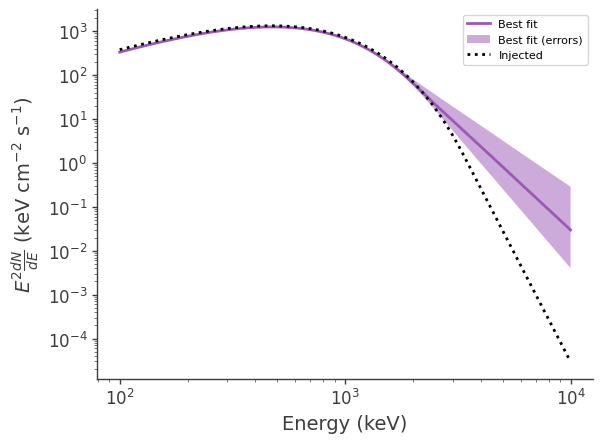

In [166]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

_ = ax.legend()

In [167]:
def compute_errors(counts):
    gaussian_error = np.zeros(len(counts))
    poisson_error  = np.zeros((2, len(counts)))

    hi_mask = (counts > 5)
    gaussian_error[hi_mask] = np.sqrt(counts[hi_mask])
    poisson_error[:,~hi_mask] = poisson_conf_interval(counts[~hi_mask], interval="frequentist-confidence", sigma=1)

    return gaussian_error, poisson_error

Plot the fitted spectrum convolved with the response, as well as the simulated source counts

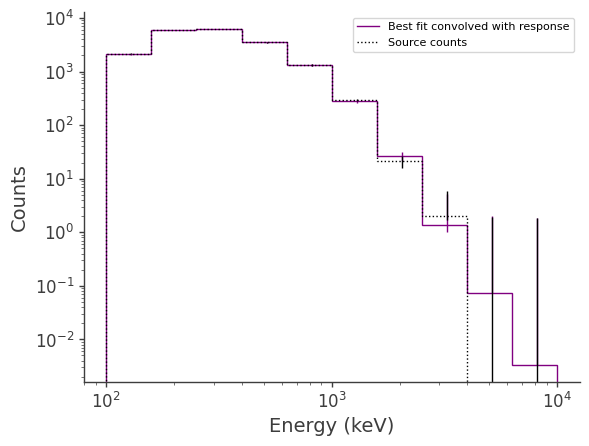

In [168]:
em_inj = grb.binned_data.project('Em').todense().contents
em_fit = expectation.project('Em').todense().contents

fit_gaussian_error, fit_poisson_error = compute_errors(em_fit)
inj_gaussian_error, inj_poisson_error = compute_errors(em_inj)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=fit_poisson_error, color='purple', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=fit_gaussian_error, color='purple', linewidth=0, elinewidth=1)
ax.stairs(grb.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, grb.binned_data.project('Em').todense().contents, yerr=fit_poisson_error, color='black', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, grb.binned_data.project('Em').todense().contents, yerr=fit_gaussian_error, color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

_ = ax.legend()

Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts

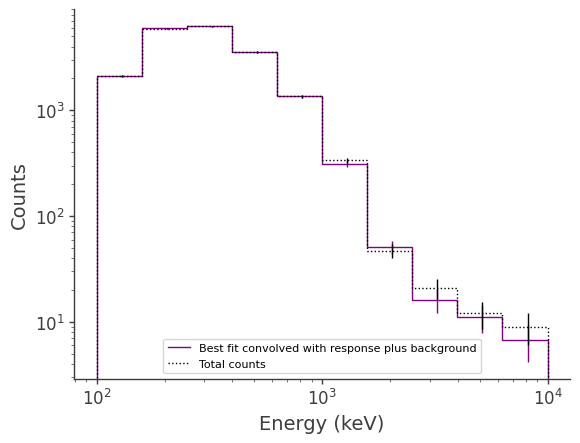

In [169]:
expectation_bkg = bkg_model.expectation(copy = True)

fit_bkg_gaussian_error, fit_bkg_poisson_error = compute_errors(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents)
inj_bkg_gaussian_error, inj_bkg_poisson_error = compute_errors(data.data.project('Em').todense().contents)

fig,ax = plt.subplots()
ax.stairs(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=fit_bkg_poisson_error, color='purple', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=fit_bkg_gaussian_error, color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=inj_bkg_poisson_error, color='black', linewidth=0, elinewidth=1)
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=inj_bkg_gaussian_error, color='black', linewidth=0, elinewidth=1)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()